# Tema 6.  Interpretabilidad de modelos

#### Contenidos:
* [6.1 Introducción](#1)
* [6.2 Interpretabilidad local: razonando las predicciones realizadas (SHAP values)](#2)
* [6.3 Interpretabilidad global del modelo](#3)
    * [6.3.1 Interpretando la importancia de las variables en el modelo](#3.1)
    * [6.3.2 ¿Cómo afectan los valores de los ejemplos al modelo?](#3.2)
* [6.4 ¿Para qué se puede utilizar la intepretabilidad del modelo?](#4)

## 6.1 Introducción <a class="anchor" id="1"></a>

Muchas personas piensan que los modelos obtenidos tras aplicar técnicas de aprendizaje automática son *cajas negras* en el sentido que ofrecen buenas predicciones pero que no permiten entender la lógica aplicada para realizarlas. Este motivo puede provocar un rechazo en la adopción de estas técnicas. Por este motivo, es muy importante poder ser capaces de interpretar los modelos (interpretabilidad global del modelo) y las predicciones que realizan (interpretabilidad local).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import model_selection

import warnings
warnings.filterwarnings('ignore')

Para aprender a utilizar las técnicas de interpretación de los modelos obtenidos vamos a utilizar un problema de clasificación en el que se debe predecir [*si una persona tiene diabetes o no*](https://www.kaggle.com/uciml/pima-indians-diabetes-database).

In [2]:
# Lectura de los datos
df = pd.read_csv('pima.csv', encoding='utf-8') # valores de entrada

# Especificamos el nombre del atributo a predecir y copiamos el contenido del DataFrame con las salidas 
    # en el que contiene el resto de información para tener un solo DataFrame
atSalida = 'Class'
df_output = df[atSalida].copy()
df.drop(atSalida, axis=1, inplace=True)

# Mostramos la distribución de las clases
print('La distribución de las clases (probabilidades a priori) del problema son:')
print(df_output.value_counts()/df_output.value_counts().sum())

# Dividimos los datos en los conjuntos de train y test
X_train, X_test, y_train, y_test = model_selection.train_test_split(df, df_output, test_size=0.25, stratify=df_output, random_state = 123)

La distribución de las clases (probabilidades a priori) del problema son:
Class
0    0.651042
1    0.348958
Name: count, dtype: float64


Como ejemplo, vamos a usar un Random Forest para resolver el problema (como el objetivo es interpretarlo no vamos a buscar los mejores valores de los híper-parámetros).

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

RF = RandomForestClassifier(n_estimators=10, random_state=0).fit(X_train, y_train)

accTrain = metrics.accuracy_score(y_train, RF.predict(X_train))*100.0
accTest = metrics.accuracy_score(y_test, RF.predict(X_test))*100.0

print('El rendimiento del random forest en train es {:.2f}% y en test es {:.2f}%'.format(accTrain, accTest))

El rendimiento del random forest en train es 97.74% y en test es 76.04%


## 6.2 Interpretabilidad local: razonando las predicciones realizadas (SHAP values) <a class="anchor" id="2"></a>

Podemos utilizar el modelo aprendido para clasificar nuevos ejemplos y obtener la probabilidad de predecir cada clase.

In [4]:
# Elegimos un ejemplo a clasificar
indice_ejemplo_a_predecir = 5
ejemplo_a_predecir = X_test.iloc[indice_ejemplo_a_predecir].values.reshape(1, -1)
clase_ejemplo_a_predecir = y_test.iloc[indice_ejemplo_a_predecir]
# Lo clasificamos y mostramos su clase y las probabilidades
probabilidades = RF.predict_proba(ejemplo_a_predecir)
clase = RF.predict(ejemplo_a_predecir)
print('La clase predicha es {} y las probabilidades son {}'.format(clase[0],probabilidades.ravel()))
print('El ejemplo es de la clase {}'.format(clase_ejemplo_a_predecir))

La clase predicha es 1 y las probabilidades son [0.2 0.8]
El ejemplo es de la clase 1


Podemos observar que la probabilidad dada por el modelo de que el ejemplo no tenga diabetes es de un 20% mientras que la de que sí tenga es de un 80%. Por este motivo, el ejemplo se predice como clase positiva (tiene diabetes) y lo acertaría.

Una pregunta que nos podríamos realizar es: ¿por qué el modelo ha dado tal predicción? Es decir, ¿qué características del ejemplo hacen que la probabilidad de la clase positiva sea mayor (o menor) que la probabilidad a priori de dicha clase?

Para dar respuesta, habitualmente se utilizan los valores SHAP (SHAP values), que permiten **interpretar el impacto (contribución) de cada variable en la predicción realizada** (en concreto de los valores del ejemplo a predecir en cada variable). 

Formalmente, el valor SHAP de una variable es la contribución marginal media ponderada de dicha variable teniendo en cuenta todas las posibles combinaciones de las variables de entrada:
* La primera combinación de variables (primer nivel) sería no tener ninguna variable, por lo que la predicción realizada vendría dada por la probabilidad a priori de tener ejempos de cada clase  (o la media de todos los ejemplos en caso de un problema de regresión).
* La segunda combinación (segundo nivel) sería tener grupos de una variable (tantos como variables). Se realizaría el aprendizaje del modelo en base a cada variable individual y se daría la predicción en base al modelo aprendido.
    * La contribución marginal de una variable sería la diferencia entre la predicción con esa variable o sin ella (combinación del nivel anterior).
* La tercera combinación (tercer nivel) sería tener grupos de dos variables (tantos como pares de variables se puedan obtener). Se realizaría el aprendizaje del modelo por cada par de variables y se realizaría la predicción en base al modelo aprendido.
    * Las contribuciones marginales de una variable serían las diferencias entre las predicciones realizadas en las parejas que tengan dicha variable y la realizada por la otra variable de la pareja de forma individual. Es decir, se mide la contribución realizada por la variable que se esté analizando.
* Este proceso se repetiría hasta alcanzar el grupo de todas las variables.

Vamos a ver un ejemplo de un problema de clasificación donde la probabilidad a priori de la clase negativa es de un 60% y la de la positiva es de un 40%. El problema tiene 3 variables de entrada (V1, V2 y V3) y al predecir un ejemplo hemos visto que la probabilidad de la clase positiva es 0.74, ¿a qué se debe dicha predicción? Vamos calcular el valor SHAP de la variable V1.

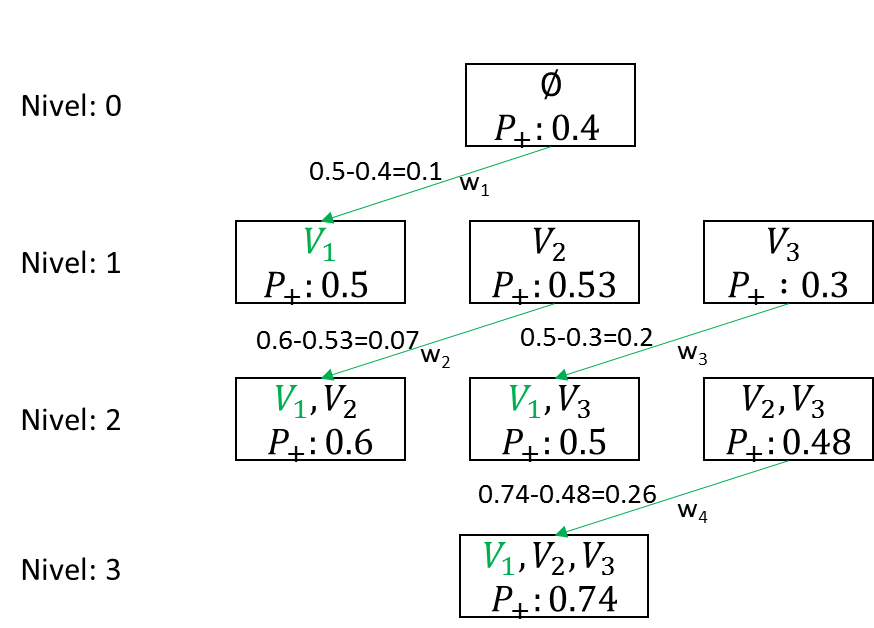

Finalmente, se realizaría la media ponderada de todas las contribuciones marginales de la variable a estudiar.
* En el ejemplo sería $SHAP_{V_1}(x) = w_1*0.1 + w_2*0.07 + w_3*0.2 + w_4*0.26$

Para ello debemos saber cómo asignar el peso a cada contribución, las reglas generales son:
* La suma de todos los pesos debe ser 1
    * En el ejemplo esto implica que $w_1 + w_2 + w_3 + w4 = 1$
* Los pesos de las contribuciones del mismo nivel deben ser iguales
    * En el ejemplo esto implica que $w_2 = w_3$
* La suma de los pesos de todas las contribuciones de cada nivel deben ser iguales
    * En el ejemplo esto implica que $w_1 = w_2 + w_3 = w_4$

¿Cómo se consigue cumplir con esas reglas? Es sencillo, el peso de cada arco debe ser igual al recíproco del número de arcos de un nivel.
* En el ejemplo esto implica que
    * $w_1 = \frac{1}{3}$
    * $w_2 = w_3 = \frac{1}{6}$
    * $w_4 = \frac{1}{3}$
* Por tanto, $SHAP_{V_1}(x) = \frac{1}{3}*0.1 + \frac{1}{6}*0.07 + \frac{1}{6}*0.2 + \frac{1}{3}*0.26 = 0.165$
    
Formalmente, el peso de cada arco del nivel $f$, dado que hay $F$ variables, es $\frac{1}{f \cdot \left(\begin{matrix}F\\f\end{matrix}\right)}$.

Este proceso implica que los valores SHAP permitan descomponer una predicción de tal forma que expliquen el motivo de que la probabilidad dada por el modelo sea diferente de la probabilidad a priori de tener ejemplos de una clase (o la media de los valores a predecir en caso de problemas de regresión).

Este proceso se realizaría para calcular el valor SHAP de cada variable $f \in F$. La suma de todos los valores SHAP sería igual a la diferencia entre la probabilidad predicha por el modelo y la probabilidad a priori de la clase.

En el ejemplo anterior, los valores SHAP de las variables $V_2$ y $V_3$ son:
* $SHAP_{V_2}(x) = 0.17$
* $SHAP_{V_3}(x) = 0.005$

Por lo que la suma de los valores SHAP de las 3 variables es 0.34 (diferencia entre la probabilidad predicha para la clase positiva y su probabilidad a priori).

NOTA: en un problema de regresión la explicación de cómo se calculan los valores SHAP es la misma pero
* El valor predicho sin variables sería la media de los valores de los ejemplos de entrenamiento
* El valor predicho por cada combinación de variables sería un valor numérico, no la probabilidad de la clase

Veamos un ejempo visual de la descomposición según la contribución de cada variable de la predicción realizada anteriormente utilizando la [*librería Shap*](https://github.com/slundberg/shap).

In [5]:
# Importamos la librería shap
import shap  

# Elegimos un ejemplo a clasificar y lo dejamos en formato Series para facilitar la interpretación de la gráfica
indice_ejemplo_a_predecir = 5
ejemplo_a_predecir = X_test.loc[X_test.index[indice_ejemplo_a_predecir]]

# Creamos un objeto de la clase TreeExplainer ya que tenemos un modelo basado en árboles de decisión
explainer = shap.TreeExplainer(RF)
# Calculamos los valores SHAP
shap_values = explainer.shap_values(ejemplo_a_predecir)

# Mostramos la descomposición creada
    # expected_value es un array con tantos valores como clases (probabilidad a priori de cada clase)
    # shap_values es una lista con tantas matrices como ejemplos; cada matriz tiene tantas filas como atributos y tantas columnas como clases del problema
        # Por tanto, cada columna de la matriz contiene el impacto de las variables en esa clase
    # Mostramos el de la clase positiva porque normalmente pensamos en predicciones en dicho término
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[:, 1], ejemplo_a_predecir)

# Si fuera un problema de regresión expected_value sería un solo valor (media de la variable a predecir) y shap_values sería un solo array
# shap.force_plot(explainer.expected_value, shap_values, data_for_prediction)

¿Cómo se interpreta el gráfico anterior?

Para empezar se puede observar que la predicción es 0.8 para la clase positiva mientras que el valor base (probabilidad a priori) es de 0.338 (porque hemos mostrado *expected_value[1]* y *shap_values[:,1]*). 

Las variables mostradas en rosa son las que implican que la probabilidad de que el ejemplo sea de la clase positiva sea mayor. El tamaño de dichas variables indica la magnitud del impacto de dicha variable en el aumento de la probabiliad. Por contra, las variables mostradas en azul son las que implican una reducción de la probabilidad de que el ejemplo sea de la clase positiva. Por ejemplo, podemos ver que el mayor impacto positivo es que la variable *PlasmaGlucose* tenga un valor de 174 seguido por el valor 36 de la variable *Age*. Por contra, la variable *SkinThickness* (con valor 22) tiene un impacto negativo en la probabiliad de clasificar el ejemplo en la clase positiva.

Si restáramos la suma de las magnitudes de las variables con impacto positivo del de las de impacto negativo, obtendríamos la distancia entre la probabilidad a priori (valor base) con respecto a la probabilidad predicha. Pese a que suene muy directo es un [*proceso complejo*](https://towardsdatascience.com/one-feature-attribution-method-to-supposedly-rule-them-all-shapley-values-f3e04534983d).

Podemos mostrar la gráfica anterior para la clase negativa. En este caso la interpretación es al revés, las variables que antes hacían aumentar la probabilidad de predecir la clase positiva ahora implican una reducción de predecir la clase negativa (y las que la reducían ahora la aumentan).

In [6]:
# Shap values para la clase negativa: análisis complementario al anterior
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[:, 0], ejemplo_a_predecir)

Si tuviéramos un problema multi-clase se podrían visualizar los valores SHAP para cada clase (*indiceClase*) modificando el índice a mostrar

    shap.force_plot(explainer.expected_value[indiceClase], shap_values[:, indiceClase], ejemplo_a_predecir)

En el ejemplo anterior se han obtenido los valores SHAP utilizando *shap.TreeExplainer* porque se ha utilizado un modelo basado en árboles de decisión. Sin embargo, la librería SHAP permite calcular los valores SHAP para cualquier tipo de modelo:
* [*shap.KernelExplainer*](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.KernelExplainer.html) permite calcular los valores SHAP aproximados con todos los tipos de modelos. A este método se le pasa el modelo con su método *predict_proba* y un dataset con el que realiza los cálculos:
    * Para datasets pequeños se le puede pasar todo el dataset (con datasets grandes es muy lento).
    * Para datasets grandes se le puede pasar un único ejemplo o utilizar, por ejemplo, KMeans para resumir el dataset.
        * Para datasets grandes se puede usar el método [*shap.explainers.Sampling*](https://shap.readthedocs.io/en/latest/generated/shap.explainers.Sampling.html) puesto que aplica un muestreo de ejemplos que acelera mucho el proceso y los resultados son similares a los obtenidos con *KernelExplainer*.
* [*shap.DeepExplainer*](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.DeepExplainer.html) permite calcular los valores SHAP para modelos de Deep Learning.

Vamos a utilizar *shap.KernelExplainer* para obtener los valores SHAP que hemos mostrado anteriormente. No son exáctamente los mismos porque son valores aproximados pero la interpretación del gráfico nos lleva a las mismas conclusiones.

In [7]:
# Uso de KernelExplainer
kernel_explainer = shap.KernelExplainer(RF.predict_proba, X_train)
kernel_shap_values = kernel_explainer.shap_values(ejemplo_a_predecir)
shap.force_plot(kernel_explainer.expected_value[1], kernel_shap_values[:, 1], ejemplo_a_predecir)

Using 576 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [8]:
# Uso de explainers.Sampling
kernel_explainer_sampling = shap.explainers.Sampling(RF.predict_proba, X_train)
kernel_shap_values_sampling = kernel_explainer_sampling.shap_values(ejemplo_a_predecir)
shap.force_plot(kernel_explainer_sampling.expected_value[1], kernel_shap_values_sampling[:, 1], ejemplo_a_predecir)

Si el modelo que se desea interpretar es una Pipeline se debe realizar un proceso en dos pasos:
* Transformamos los datos utilizando todos los componentes de la Pipeline menos el modelo de predicción.
* Creamos el Explainer adecuado de los valores SHAP pasando solamente el modelo de predicción de la Pipeline.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipe = Pipeline([('estandarizacion', StandardScaler()), ('RF', RandomForestClassifier(n_estimators=10, random_state=0))])
pipe.fit(X_train, y_train)

Pipeline(steps=[('estandarizacion', StandardScaler()),
                ('RF',
                 RandomForestClassifier(n_estimators=10, random_state=0))])

In [10]:
# Transformamos todos los datos utilizando todos los componentes de la Pipeline excepto el modelo de predicción
datos = pipe[:-1].transform(X_train)
# Creamos un objeto de la clase TreeExplainer y le pasamos el modelo de predicción
    # si no fuera basado en árboles de decisión tendría que ser KernelExplainer y con modelo.predict_proba
kernel_explainer = shap.TreeExplainer(pipe['RF'], datos)
# Calculamos los valores SHAP del ejemplo a predecir (lo transformamos a un vector para que encajen las dimensiones esperadas)
ejemplo_A_Explicar = pipe[:-1].transform(ejemplo_a_predecir.values.reshape(1,-1))
kernel_shap_values = kernel_explainer.shap_values(ejemplo_A_Explicar)

# Mostramos visualmente el resultado
shap.initjs()
shap.force_plot(kernel_explainer.expected_value[1], kernel_shap_values[:, :, 1], ejemplo_a_predecir)

In [11]:
# Transformamos todos los datos utilizando todos los componentes de la Pipeline excepto el modelo de predicción
datos = pipe[:-1].transform(X_train)
# Calculamos los valores SHAP del ejemplo a predecir (lo transformamos a un vector para que encajen las dimensiones esperadas)
ejemplo_A_Explicar = pipe[:-1].transform(ejemplo_a_predecir.values.reshape(1,-1))

# Uso de explainers.Sampling
kernel_explainer_sampling = shap.explainers.Sampling(pipe['RF'].predict_proba, datos)
kernel_shap_values_sampling = kernel_explainer_sampling.shap_values(ejemplo_A_Explicar)
shap.force_plot(kernel_explainer_sampling.expected_value[1], kernel_shap_values_sampling[:, :, 1], ejemplo_a_predecir)

  0%|          | 0/1 [00:00<?, ?it/s]

## 6.3 Interpretabilidad global del modelo <a class="anchor" id="3"></a>

## 6.3.1 Interpretando la importancia de las variables en el modelo <a class="anchor" id="3.1"></a>

Una de las preguntas básicas que se pueden plantear tras entrenar un modelo es: ¿Qué variables tienen el mayor impacto en las predicciones realizadas por dicho modelo? A este concepto se le llama **feature importance** (importancia de las variables) y hay muchas formas de medirla.

Para ello vamos a ver dos métodos
* Utilizando la técnica conocida como **permutation importance**
* Utilizando la **agregación de los SHAP values** que hemos visto anteriormente. 

En el caso de los árboles de decisión o de los Random Forest podemos mostrar gráficamente la propiedad *feature_importance_*. Sin embargo, esta propiedad determina cómo afectan las diferentes variables a la hora de entrenar el modelo.

### Permutation importance

La primera técnica que vamos a utilizar es la llamada **permutation importance** puesto que comparada con otros métodos:
* Es fácil de calcular.
* Su uso está muy extendido.
* Es fácil de entender.

Este método parte de un modelo entrenado para determinar la importancia de cada variable en dicho modelo. Es decir, ni el modelo ni sus predicciones se cambian. Lo que se hace es responder a la pregunta, ¿**cómo afectaría al rendimiento del modelo** realizar un intercambio aleatorio de los valores de una variable (dejando todas las demás, incluyendo la variable a predecir, en el orden original)? 

La reordenación aleatoria de los valores de una variable debería implicar realizar peores predicciones puesto que los ejemplos resultantes no corresponden con las observaciones reales:
* Si la variable es importante, esta reordenación causará una gran reducción del rendimiento.
* Si la variable no es relevante, la reordenación no causará una reducción del rendimiento.

En concreto, el proceso es el siguiente:
* Entrena un modelo de predicción y realiza las predicciones con él.
    * Reordenar aleatoriamente los valores de una variable y realizar la predicción utilizando el dataset resultante. Con las predicciones realizadas con el dataset reordenado y las predicciones originales se calcula la pérdida de rendimiento sufrida por la reordenación. La reducción del rendimiento cuantifica la importancia de la variable que ha sido reordenada: cuanta más pérdida más importante es para el modelo.
        * Repite el proceso (evidentemente con el dataset original) con todas las variables para calcular la importancia de cada una de ellas.
    * Para tener en cuenta el efecto de la aleatoriedad, se puede repetir el proceso varias veces (con semillas diferentes).
    
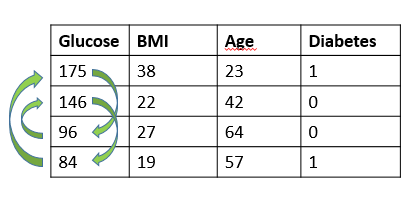

Scikit-learn ofrece una implementación de esta técnica en la función [*permutation_importance*](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html#sklearn.inspection.permutation_importance) de la librería [*inspection*](https://scikit-learn.org/stable/api/sklearn.inspection.html). Por defecto, el número de repeticiones del proceso de reordenación para cada variable (*n_repeats*) es 5, por lo que el resultado que se obtiene es la media de la pérdida de rendimiento y la desviación estándard ($\pm$) de las repeticiones realizadas. Además, también permite utilizar diferentes métricas de rendimiento (*scoring*).

In [28]:
from sklearn.inspection import permutation_importance

# Obtenemos la importancia de cada variable
result = permutation_importance(RF, X_train, y_train, scoring='accuracy', random_state=1) 
# Obtenemos los índices de las variables ordenadas de mayor a menor
sorted_importances_idx = result.importances_mean.argsort()

# Creamos un DataFrame con toda la información y lo mostramos
feature_importances = pd.DataFrame([], index = X_train.columns[sorted_importances_idx[::-1]], columns=['Media','Desviación Estándard'])
feature_importances['Media'] = result.importances_mean[sorted_importances_idx[::-1]]
feature_importances['Desviación Estándard'] = result.importances_std[sorted_importances_idx[::-1]]
feature_importances

,Media,Desviación Estándard
PlasmaGlucose,0.278597,0.012130
BodyMassIndex,0.166217,0.013703
DiabetesPedigree,0.160505,0.011035
Age,0.153346,0.007295
BloodPressure,0.092263,0.010734
SkinThickness,0.090907,0.008264
NumberTimesPregnant,0.085561,0.010761
Insulin,0.066687,0.003360


El resultado anterior es una tabla ordenada de mayor a menor importancia de las variables para el modelo. Es decir, la reducción del rendimiento medido según la métrica especificada en *scoring* que [puede ser cualquiera de las permitidas en Scikit-learn](https://scikit-learn.org/stable/modules/model_evaluation.html#common-cases-predefined-values). Para cada variable:
* El primer valor es la media de la reducción del rendimiento tras reordenarla aleatoriamente el número de veces que se haya fijado.
    * Se pueden obtener valores negativos en caso de que las variables no sean importantes (deberían tener un valor cercano a 0) y la reordenación aleatoria de los valores cause por casualidad una mejora del rendimiento obtenido.
* El segundo valor es la desviación estándar obtenida en las repeticiones realizadas.

También podemos mostrar el resultado anterior de forma visual y utilizando box plots.

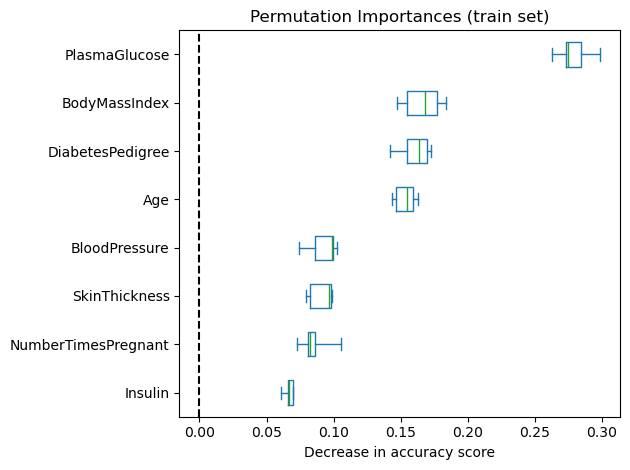

In [29]:
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_train.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

La segunda opción que vamos a ver es utilizar los valores SHAP anteriores. En este caso, como se está analizando la importancia de cada variable de forma global, lo que se hace es calcular los valores SHAP de todos los ejemplos y se hace la media para cuantificar la importancia de la variable de forma global. Además, la librería *shap* tiene un método llamado *summary_plot* que permite visualizar dicha importancia para cada una de las clases del problema (en caso de problemas de clasificación).

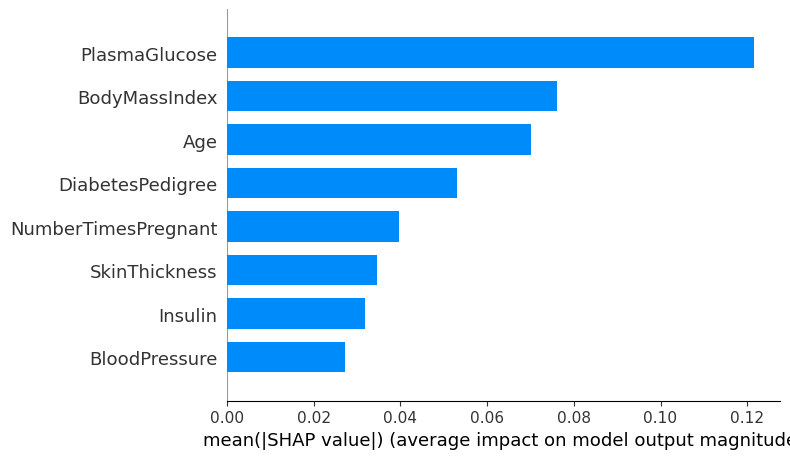

In [30]:
# Calculamos los valores SHAP para obtener la importancia global de cada variable en el modelo
shap_values = shap.TreeExplainer(RF).shap_values(X_train)
# Mostramos el resultado en un gráfico de barras (plot_type="bar")
shap.summary_plot(shap_values[:, :, 1], X_train, plot_type="bar")

El uso de los valores SHAP puede ofrecer un mayor nivel de detalle puesto que los resultados anteriores permiten saber las variables más importantes para el modelo pero no conocemos el motivo de que sean importantes. Es decir, si en el gráfico anterior el resultado dice que una variable tiene una importancia media puede ser porque:
* Unos pocos ejemplos hacen que la importancia de esa variable aumente pero que para el resto de ejemplos no tenga mucho efecto.
* Tiene una importancia media para todos los ejemplos.

La librería *shap* ofrece formas de visualizar los valores SHAP de grupos de ejemplos. Es decir, sería como *desagregar* el resultado de la gráfica anterior y verlo para cada ejempo que ha sido utilizado para generarla. Lo único que hay que hacer es no especificar que queremos realizar un gráfico de barras en el método *summary_plot*.

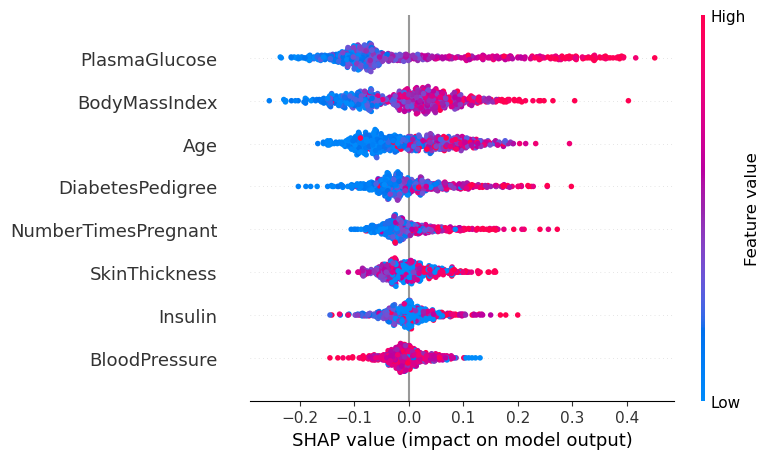

In [31]:
# Calculamos los valores SHAP para obtener la importancia global de cada variable en el modelo
shap_values = shap.TreeExplainer(RF).shap_values(X_train)
# Mostramos el resultados sin agrupar: sin hacer un gráfico de barras
    # En caso de problemas de regresión se mostraría shap_values
shap.summary_plot(shap_values[:, :, 1], X_train)

Al igual que pasaba al interpretar la predicción de un ejemplo, se puede visualizar la interpretabilidad para cualquier otra clase (en este caso la negativa).

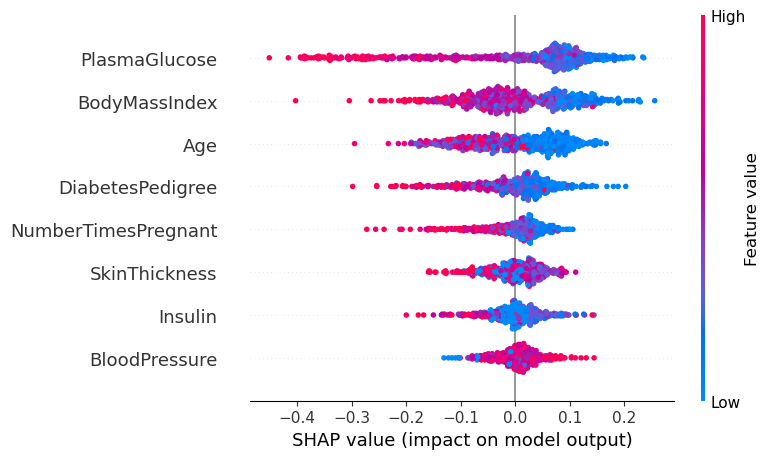

In [32]:
shap.summary_plot(shap_values[:, :, 0], X_train)

**¿Cómo se interpreta el gráfico anterior?**

El gráfico está compuesto de muchos puntos (tantos como ejemplos por cada variable) y muestra la siguiente información:
* Importancia de la variable: Las variables están ordenadas por importancia (de mayor, arriba, a menor, abajo).
* Impacto: la localización horizontal de cada punto determina si el efecto de ese valor es aumentar (a la derecha de la línea vertical) o disminuir (a la izquierda) la probabilidad de predecir la clase para la que ha sido creado el gráfico (la positiva en nuestro caso, *shap_values[1]*).
    * En caso de problemas de regresión sería aumentar o disminuir el valor predicho.
* Valor original del ejemplo: los ejemplos con valores altos o bajos para la variable están coloreados en rojos y azules, respectivamente (con una degradación gradual).
* Correlación entre el valor del ejemplo y el impacto
    * En este caso podemos ver una correlación positiva entre las 5 primeras variables y la probabilidad de tener diabetes.
    * Para las dos últimas variables parece que no hay correlación.
    * Se podría observar una correlación negativa en caso de que los rojos estuvieran a la izquierda de la línea vertical y los azules a la derecha. 
    
El análisis de este gráfico puede dar mucha información de los motivos por los que las variables son importantes para un modelo.

## 6.3.2 ¿Cómo afectan los valores de los ejemplos al modelo? <a class="anchor" id="3.2"></a>

Finalmente, una vez que conocemos las variables más importantes para un modelo de forma global en términos de su **feature importance**, puede ser interesante conocer cómo afectan los valores de esas variables en el modelo. Por ejemplo, en el problema con el que estamos ilustrando este tema, podemos responder preguntas como: ¿aumenta la probabilidad de tener diabetes conforme nos hacemos mayores?. En la mayoría de los casos la influencia no será monótona y por ello se necesitan herramientas que ayuden a comprender las relaciones complejas entre las variables de entrada y la salida del modelo.

Para ello, una técnica que se utiliza a menudo los las gráficas de dependencia parcial (**partial dependence plots**). Estas gráficas se pueden interpretar de forma similar a los valores de los coeficientes de los modelos lineales (como la regresión lineal o la logística) pero pueden captar patrones más complejos al ser utilizados para explicar modelos más complejos.

Al igual que pasaba con la técnica *permutation importance*, las gráficas de dependencia parcial se calculan tras haber realizado el aprendizaje de un modelo. Con este modelo, lo que tratan de visualizar es el efecto marginal de una variable en la predicción del modelo mostrando la salida (probabilidad o valor) media del modelo en función de los diferentes valores de la variable. Para ello, el proceso que se realiza es:
* Se coge un ejemplo y se realiza la predicción de dicho ejemplo con todos los posibles valores de la variable analizada (dejando fijos el resto de valores). De este modo, para ese ejemplo, se puede observar cómo cambiaría la predicción en función de los valores de la variable analizada.
* Como con un solo ejemplo se podría tener un comportamiento raro por las interacciones entre las variables, se realiza el proceso para todos los ejemplos. Por tanto, para cada posible valor de la variable a analizar tendremos tantas predicciones como ejemplos. 
* Para visualizar el comportamiento de forma global, para cada posible valor de la variable (se muestra en el eje X) se muestra la media de todas las predicciones que lo hayan utilizado (eje Y).

Como resultado, se obtiene una gráfica que muestra cómo cambiaría la predicción del modelo ante diferentes valores de la variable analizada. Es decir, permite determinar si la relación entre la salida y la variable analizada es lineal, monótona o más compleja.

Por ejemplo, si tuviéramos un problema con 3 ejemplos (e1, e2 y e3) caracterizados por 3 variables de entrada (X1, X2 y X3)

| | X1  | X2  | X3  |
|----|-----|-----|-----|
|e1| e11 | e12 | e13 | 
|e2| e21 | e22 | e23 | 
|e3| e31 | e32 | e33 | 

Para analizar la variable X1 (asumiendo que tiene 3 valores diferentes: e11, e21 y e31) lo que haríamos sería crear un nuevo dataset como el mostrado en la siguiente tabla (cada grupo serían los ejemplos derivados de cada ejemplo original). Para cada nuevo ejemplo realizaríamos la predicción (Pred.) con el modelo entrenado previamente:

| X1  | X2  | X3  | Pred.  |
|-----|-----|-----|----|
| e11 | e12 | e13 | Y11 | 
| e21 | e12 | e13 | Y21 | 
| e31 | e12 | e13 | Y31 | 
|-----|-----|-----|----|
| e11 | e22 | e23 | Y12 |
| e21 | e22 | e23 | Y22 |
| e31 | e22 | e23 | Y32 |
|-----|-----|-----|----|
| e11 | e32 | e33 | Y13 | 
| e21 | e32 | e33 | Y23 | 
| e31 | e32 | e33 | Y33 | 

Finalmente, se realiza la media para cada grupo de predicciones asociadas a cada valor diferente de la variable analizada y se muestran esas medias en función de los valores de la variable.

|eje X |e11  | e21  | e31  | 
|-----|-----|-----|----|
|eje Y | Media(Y11, Y12, Y13)  | Media(Y21, Y22, Y23)  | Media(Y31, Y32, Y33)  |

Scikit-learn provee la función [*PartialDependenceDisplay*](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html#sklearn.inspection.PartialDependenceDisplay) de la librería *inspection* que premite crear dichos gráficos. De hecho, para facilitar la creación de los mismos, nos ofrece el método [*from_estimator*](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html#sklearn.inspection.PartialDependenceDisplay.from_estimator), cuyos argumentos de entrada son:
* El modelo entrenado.
* Los ejemplos sobre los que realizar el análisis.
* La variable (o variables) que deseamos analizar.
* Se puede controlar el número de valores diferentes de la variable a analizar (*grid_resolution* cuyo valor por defecto es 100).
* En el caso de problemas de clasificación, podemos especificar la clase para la que deseamos obtener la probabilidad (*target=nombreClase*).

La librería [*PDPBox library*](https://pdpbox.readthedocs.io/en/latest/) se utiliza mucho para mostrar este tipo de gráficos de dependendia parcial.

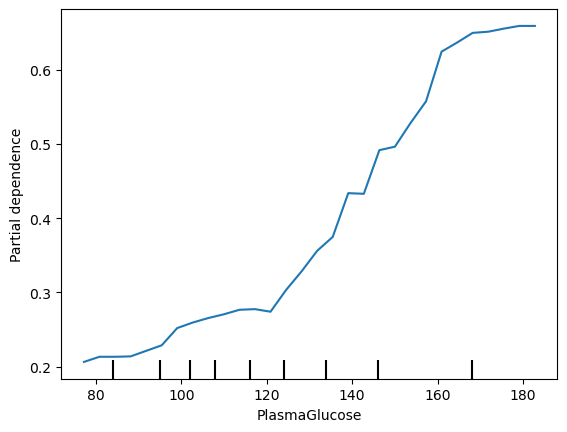

In [33]:
from sklearn.inspection import PartialDependenceDisplay

# Llamamos a la función de Scikit con la variable PlasmaGlucose puesto que es la más importante según las técnicas anteriores
PartialDependenceDisplay.from_estimator(RF, X_train, ['PlasmaGlucose'], grid_resolution=30, target=1);

En el gráfico anterior podemos observar que la probabilidad de predecir que padece diabetes tiene una correlación positiva con la variable *PlasmaGlucose*, especialmente relevante a partir del valor 125.

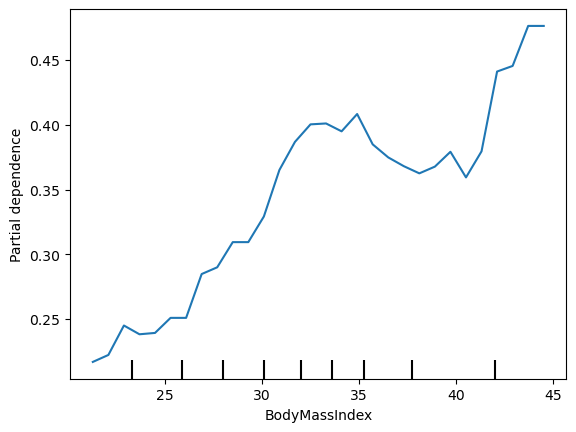

In [34]:
# Realizamos el mismo proceso para la segunda variable más importante

# Llamamos a la función de Scikit con la variable PlasmaGlucose puesto que es la más importante según las técnicas anteriores
PartialDependenceDisplay.from_estimator(RF, X_train, ['BodyMassIndex'], grid_resolution=30, target=1);

En este caso, la probabilidad de predecir la clase diabetes aumenta conforme al valor de la variable *BodyMassIndex* hasta 35 más o menos. A partir de ese punto disminuye levemente y finalmente aumenta notablemente si el valor de la variable es mayor que 42 más o menos.

Otra posibilidad sería mostrar las gráficas de dependencia parcial en base a la interacción entre dos variables. Para ello, lo único que hay que hacer es determinar la lista de variables a analizar.

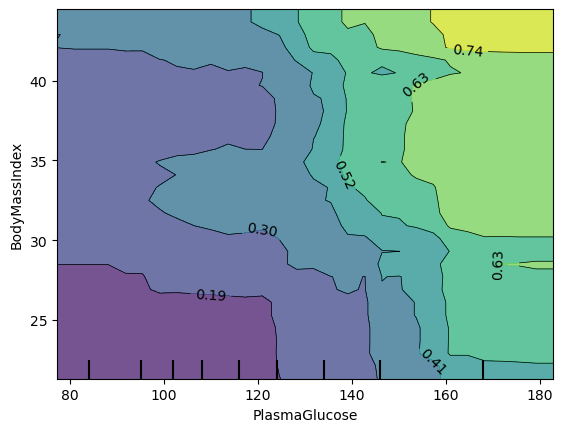

In [35]:
# Creamos la gráfica en base a la interacción entre las dos variables más importantes
PartialDependenceDisplay.from_estimator(RF, X_train, [['PlasmaGlucose', 'BodyMassIndex']], grid_resolution=30, target=1);

En el gráfico anterior se muestra cómo la interacción entre las dos variables permite aumentar la probabilidad de predecir diabetes. En concreto, cuanto mayor es el valor de ambas variables a la vez más aumentará la probabilidad de predecir la clase diabetes.

Realmente, el uso de estas gráficas se realiza de manera conjunta. Es decir, se muestra a la vez la gráfica de dependencia parcial individual de las dos variables y la de su interacción.

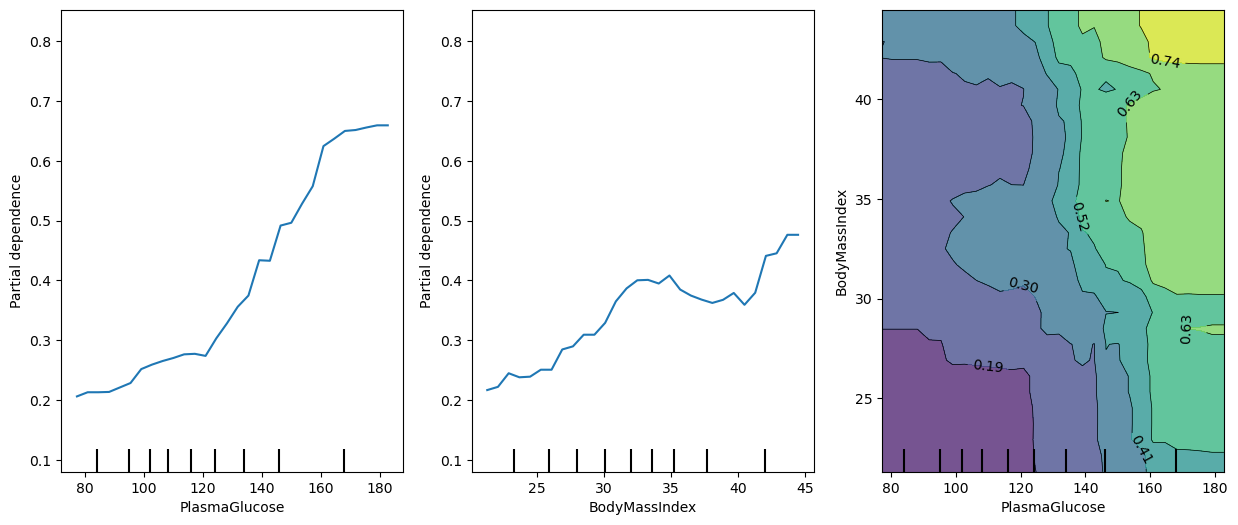

In [36]:
# Creamos la gráfica donde mostramos la serie de gráficas de dependecia parcial
_, ax = plt.subplots(ncols=3, figsize=(15, 6))
PartialDependenceDisplay.from_estimator(RF, X_train, ['PlasmaGlucose', 'BodyMassIndex', ['PlasmaGlucose', 'BodyMassIndex']], grid_resolution=30, target=1, ax=ax);

Fortalezas de los gráficos de dependencia parcial:
* Su cálculo es intuitivo y fácil de implementar.
* Su interpretación es clara si las variables no están correlacionadas.

Debilidades de los gráficos de dependencia parcial:
* El número realista de variables a analizar es dos: las interacciones entre más de dos variables tendrían que mostrarse en gráficas de más de dos dimensiones.
* No muestran la distribución de los datos: puede provocar que sobrevaloremos regiones que prácticamente no tienen datos. Se podría solucionar mostrando en el eje X el histograma de la variable.
* Asumen que las variables son independientes entre ellas (que no estén correlacionadas). Cuando las variables están correlacionadas pueden generar ejemplos en regiones del espacio de entrada con muy poca probabilidad de que existan ejemplos. Por ejemplo, una persona que mide 2.17 metros es muy poco probable que pese 53 Kilogramos.
* Se puede perder la heterogeneidad en los resultados por el efecto de la media: para unos ejemplos puede existir una asociación positiva y para otros negativa. Esto se puede visualizar mostrando las curvas individuales de cada ejemplo (Individual Conditional Expectation (ICE): se pueden mostrar incluyendo *kind='individual'* en la llamada a la función *plot_partial_dependence*).

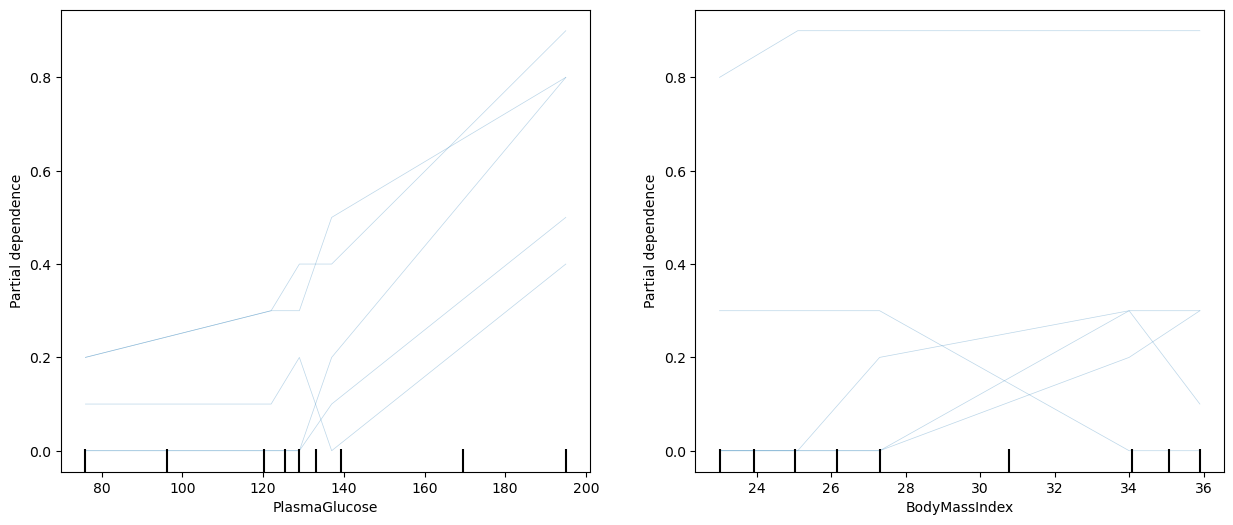

In [37]:
# Creamos la gráfica donde mostramos la gráficas de dependecia parcial de las dos variables más importantes 
    # pero mostrando las curvas individuales (ICE)
    
_, ax = plt.subplots(ncols=2, figsize=(15, 6))
PartialDependenceDisplay.from_estimator(RF, X_train[:5], ['PlasmaGlucose', 'BodyMassIndex'], kind='individual', grid_resolution=30, target=1, ax=ax);

Al igual que en el caso anterior, los valores SHAP nos pueden ofrecer más información que las gráficas de dependencia parcial. Por ejemplo, nos permiten visualizar la distribución de los efectos de los diferentes valores en la predicción. De este modo podemos resolver dudas como: ¿la salida para un valor es constante independientemente del resto de variables? o por contra, ¿varía mucho en función de los valores de otras variables? 

Para aclarar este tipo de cuestiones, la librería *shap* ofrece la función [*dependence_plot*]() cuyos argumentos de entrada son:
* La variable a analizar.
* Los valores SHAP (de la clase deseada en caso de clasificación).
* Los ejemplos a utilizar para generar la gráfica.
* La variable con la que analizar la interacción (*interaction_index* que en caso de no establecerse, la propia función escoge la variable más adecuada para generar la gráfica).

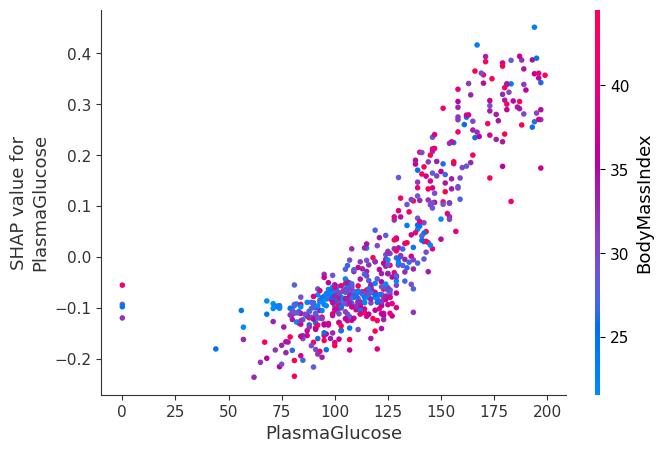

In [38]:
# Calculamos los valores SHAP para obtener la gráfica de dependencia parcial
explainer = shap.TreeExplainer(RF).shap_values(X_train)
# Creamos la gráfica para la variable PlasmaGlucose porque es la más importante
shap.dependence_plot('PlasmaGlucose', shap_values[:, :, 1], X_train, interaction_index="BodyMassIndex")

**¿Cómo interpretar la gráfica?**

Cada punto es un ejemplo cuya:
* Localización horizontal: es el valor de ese ejemplo en la variable analizada. 
* Localización vertical: muestra el efecto de dicho valor en la predicción (en este caso aumentar/disminuir la probabilidad de predecir la clase diabetes).
   * En la gráfica anterior, se ve una tendencia al alza. Es decir, un mayor valor de la variable *PlasmaGlucose* implica aumentar la probabilidad de predecir la clase diabetes.

La dispersión de la gráfica sugiere que otras variables deben interactuar con la analizada para realizar la predicción puesto que en caso contrario tendríamos una línea perfecta. Por ejemplo, en la figura posterior destacamos dos ejemplos cuyo valor de la variable es similar y el efecto en la predicción es muy diferente: uno la deja prácticamente igual mientras que el otro la aumenta notablemente.

<!-- ![image.png](attachment:image.png) -->
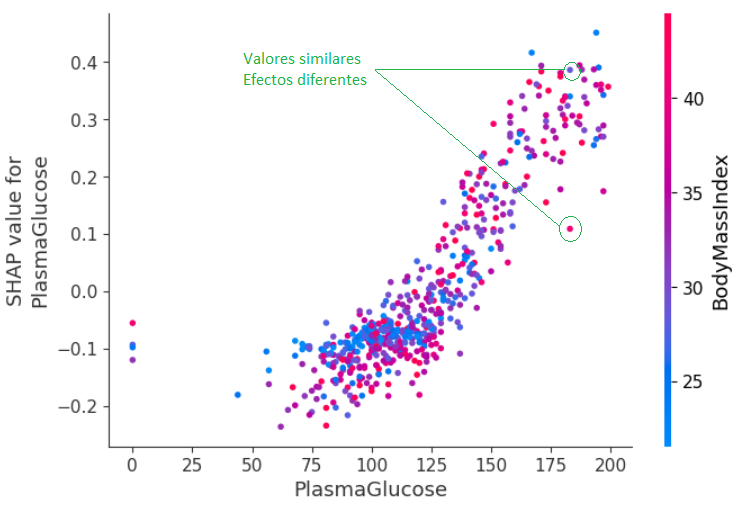

Para tratar de dar respuesta al comportamiento anterior tenemos otro componente de la gráfica que es el color de los puntos. Los puntos se colorean en base al valor del ejemplo con la variable elegida para mostrar la interacción (los ejemplos valores altos de esta variable se colorean en rojo mientras que si tienen valores bajos se colorean en azul). En el caso de los dos ejemplos anteriores, podemos observar que el ejemplo que aumenta la probabilidad notablemente tiene también un valor alto en la variable *BodyMassIndex* mientras que el que la mantiene tiene un valor medio-bajo de dicha variable.

Esta gráfica puede dar mucha información y hay que analizarlas con detenimiento.

Finalmente, si quisiéramos mostrar las variables que más podrían interactuar con la variable a analizar, podríamos hacerlo mediante la función *approximate_interactions* de la librería *shap*. Dicha función devuelve los índices de las variables que más interactuan con la analizada de mayor a menor aparición.

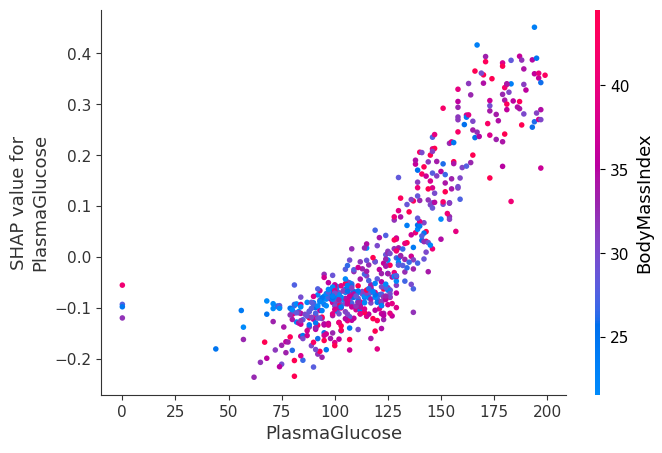

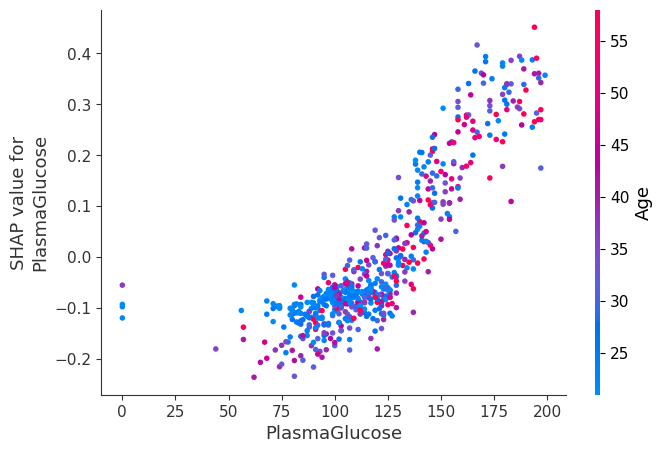

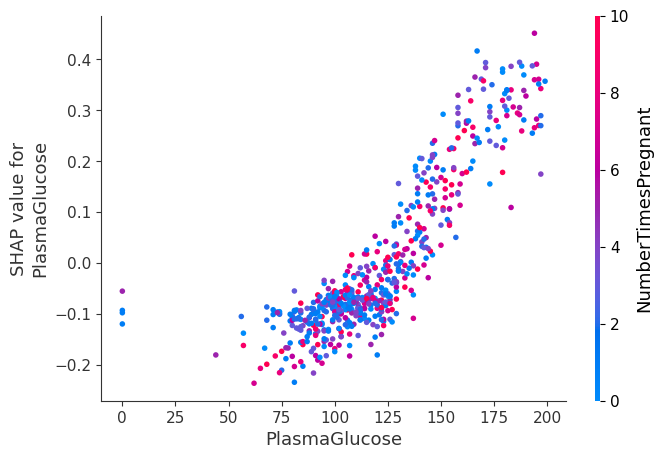

In [39]:
# Utilizamos shap.approximate_interactions para determinar las variables que más podrían interactuar con Plas
inds = shap.approximate_interactions('PlasmaGlucose', shap_values[:, :, 1], X_train)

# Creamos una gráfica para cada una de las 3 con mayor interacción
for i in range(3):
    shap.dependence_plot('PlasmaGlucose', shap_values[:, :, 1], X_train, interaction_index=inds[i])

## 6.4 ¿Para qué se puede utilizar la intepretabilidad del modelo? <a class="anchor" id="4"></a>

La interpretación de los modelos puede tener muchos usos, algunos de ellos son:

    * Asesorar los procesos de toma de decisión
    * Impulsar la adopción de las técnicas de aprendizaje automático
    * Dar información al proceso de ingeniería de variables
    * Búsqueda de errores: depuración de errores
    * Asesorar la recogida futura de datos


* Asesorar los procesos de toma de decisión

Aunque en la actualidad hay muchas decisiones que se realizan de forma automática por los modelos (recomendación de series en plataformas de streaming por ejemplo), las decisiones importantes se suelen tomar por las personas. Para tomar dichas decisiones, la propia interpretación del modelo puede ser más importante que las predicciones tomadas por el sistema.

* Impulsar la adopción de las técnicas de aprendizaje automático

Relacionado con el punto anterior está el hecho de que muchas personas no confían en las predicciones realizadas por un modelo para tomar decisiones importantes puesto que no es raro que los datos contengan errores. De este modo, si los modelos generados se pueden interpretar, la confianza en los mismos aumentará y será más fácil que se utilicen en procesos de toma de decisión incluso por personas con poco conocimiento en el tema.

* Dar información al proceso de ingeniería de variables

Como vimos en temas anteriores, la ingeniería de variables se utiliza habitualmente para mejorar la capacidad de predicción de los modelos. Para ello, se creaban nuevas variables o se transformaban las originales. Muchas veces este proceso se realiza solamente en base a la intuición por falta de conocimiento del problema a resolver. Para ayudar en estos procesos, es interesante entender el modelo generado para conocer las variables más importantes o cómo afectan los valores de los ejemplos en las predicciones realizadas. De este modo, se puede facilitar el proceso de ingeniería de variables puesto que tendremos información extra como por ejemplo, saber qué variables son las más importantes y enfoncar la generación de nuevas variable en base a ellas.

* Búsqueda de errores: depuración de errores

El código realizado para abordar un problema de predicción puede ser complejo y por tanto, hay margen para cometer errores y/o incurrir en *data leakage*. Por tanto, para depurar los errores cometidos puede ser útil entender el modelo de forma que ayude a identificarlos como primer paso para solucionarlos.

* Asesorar la recogida futura de datos

Al abordar problemas donde exista un control sobre los datos puede ser interesante recoger nueva información de los mismos. Sin embargo, esta recogida puede ser cara o le pueden poner pegas. Si entendemos los modelos podemos argumentar que dicha información ayudará a mejorar el rendimiento de los sistemas.